In [1]:

import pandas as pd
import seaborn as sns
import numpy as np
from glob import glob

from neuron_morphology.swc_io import morphology_from_swc
import matplotlib.pyplot as plt
%matplotlib inline

An error occurred: module 'importlib.metadata' has no attribute 'packages_distributions'


/opt/conda/lib/python3.9/site-packages/google/api_core/_python_version_support.py:237: FutureWarning: You are using a non-supported Python version (3.9.12). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)


In [114]:
df = pd.read_csv("/scratch/LC_soma_shapes.csv", index_col="id")
df.head()


,soma,soma_offset,radii,volume,rsquared,primary_axis,path,brain
id,,,,,,,,
N010-685222,[14720.6944 11631.7978 16186.722727],[ 0.42742857 -7.69371429 -4.57142857],[ 17.34029011 26.21208166 107.89902847],205430.070382,0.611328,[-0.89194859 -0.43279558 -0.13082697],/data/lc_image_space_reconstructions/685222-im...,685222
N038-685222,[14449.910692 9914.868864 10556.101253],[-2.3936 0.5984 -7.2 ],[17.74396407 24.58430878 67.40225395],123160.567282,0.743368,[-0.89232505 -0.36383261 -0.26717381],/data/lc_image_space_reconstructions/685222-im...,685222
N008-685222,[15115.202169 11593.030881 16119.537637],[-2.992 1.088 -6.90909091],[ 19.40753696 24.86107112 100.82514182],203773.501757,0.614664,[-0.9765063 -0.20017874 -0.07977423],/data/lc_image_space_reconstructions/685222-im...,685222
N009-685222,[15033.155651 11621.781787 16276.059435],[-1.7952 -5.6848 -2.8 ],[ 17.70722168 23.80767338 112.44292026],198558.327313,0.772748,[-0.91156984 -0.34482605 -0.22390942],/data/lc_image_space_reconstructions/685222-im...,685222
N026-685222,[15364.571216 11265.093714 10624.452406],[-6.64888889 -9.64088889 10.22222222],[18.17741418 37.5293947 52.21438967],149204.691137,0.692856,[0.95744477 0.26318416 0.11846353],/data/lc_image_space_reconstructions/685222-im...,685222


In [115]:

for col in ["radii", "primary_axis", "soma_offset", "soma"]:
    df[col] = df[col].fillna("[NaN NaN NaN]")
    df[col] = df[col].str.replace(r"\[\s*|\s*\]", "", regex=True).str.split(r"\s+")
    # move column of lists to separate columns
    df = df.assign(
        **{f"{col}_{i}": df[col].apply(lambda x: float(x[i])) for i in range(3)}
    )


In [116]:
from collections import OrderedDict
def intersection_points(m, cutoff = 100):
    root = m.get_root()
    hits = OrderedDict()
    record = {}
    # hits[root["id"]] = root
    def visit(node):
        # c = m.get_compartment_for_node(node)
        # if c is None:
        #     return
        # if (cutoff > m.euclidean_distance(root, c[0]) and cutoff < m.euclidean_distance(root, c[1])):
            # hits[node["id"]] = c[0]
        record["stop"] = False
        if node["type"]==1:
            return
        if node["type"]==3:
            is_second_branch = len(m.get_children(node)) > 1
            if cutoff < m.euclidean_distance(root, node) or is_second_branch:
                hits[node["id"]] = node
                record["stop"] = True
        else:
            # not dendrite or soma
            record["stop"] = True
        return
    def cb(node_id):
        if record["stop"]:
            # stop traversal
            return []
        else:
            nested_ids = m.child_ids([node_id])
            children = [nid for nids in nested_ids for nid in nids]
            if len(children) > 1:
                record["branch_root"] = node_id
            return children

    m.breadth_first_traversal(visit, cb)
    return hits

def get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5):
    val = 0.0
    aligned_avg = 0.0
    avg0 = np.array([0,0,0])
    avg1 = np.array([0,0,0])
    avg2 = np.array([0,0,0])
    # cos2_vals = []
    n = len(stems)
    primary_axis = np.array(primary_axis)
    primary_axis = primary_axis / np.linalg.norm(primary_axis)
    vecs = []
    for stem in stems.values():
        vec = np.array([float(stem[i]) for i in "xyz"]) - np.array(soma)
        vec = vec / np.linalg.norm(vec)
        vecs.append(vec.astype(float))

        avg0 = avg0 + (vec * np.sign(vec[0])/n)
        avg1 = avg1 + (vec * np.sign(vec[1])/n)
        avg2 = avg2 + (vec * np.sign(vec[2])/n)
        aligned = np.abs(np.dot(vec, primary_axis))
        aligned_avg += aligned/n
        if aligned**2 > cos2_cutoff:
            val += 1.0/n
    vectors = np.array(vecs)
    S = vectors.T @ vectors / len(vectors)
    eigenvalues, eigenvectors = np.linalg.eigh(S)
    avg, norm_avg = eigenvectors[:, 2], np.sqrt(eigenvalues[2])
    # avg_candidates = [avg0, avg1, avg2]
    # avg = max(avg_candidates, key=lambda x: np.linalg.norm(x))
    # norm_avg = np.linalg.norm(avg)
    # abs_cos = np.abs(np.dot(avg, primary_axis))/norm_avg
    abs_cos = np.abs(np.dot(avg, primary_axis))
    return val, aligned_avg, norm_avg, abs_cos

In [117]:
import bipolarity as b
from tqdm import tqdm

In [118]:

# names = ["aligned_bipolar_frac","aligned_bipolarity","abs_bipolarity", "cos_primary_axis"]
# names_offset = [x+"_offset" for x in names]
# df[names] = None
# df[names_offset] = None
# df["num_stems"] = None
# # cos2_vals = []
# # cos2_vals_offset = []
# index = []
# for swc in tqdm(glob("/data/lc_image_space_reconstructions/*/*.swc")[:]):
#     id = swc.split("/")[-1][:11]
#     if id not in df.index:
#         # print(f"missing {id}")
#         continue
#     index.append(id)
#     morph = morphology_from_swc(swc)
#     # morph_soma = [morph.get_soma()[i] for i in "xyz"]
#     # morph soma == spreadsheet soma

#     r2 = float(df.loc[id, "radii_2"])
#     r2 = 50
#     stems = intersection_points(morph, cutoff=r2)
#     df.loc[id, "num_stems"] = len(stems)

#     soma = df.loc[id, [f"soma_{i}" for i in range(3)]].values
#     primary_axis = df.loc[id, [f"primary_axis_{i}" for i in range(3)]].values
#     df.loc[id, names] = get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5)
#     # cos2_vals.append(vals)

#     offset_soma = soma + df.loc[id, [f"soma_offset_{i}" for i in range(3)]].values
#     df.loc[id, names_offset] = get_bipolarity(offset_soma, stems, primary_axis, cos2_cutoff=0.5)
#     # cos2_vals_offset.append(vals)


In [119]:
from importlib import reload
reload(b)

<module 'bipolarity' from '/code/bipolarity.py'>

In [120]:
id = "N016-685221"
swc = "/data/N016-685221-PG.swc"
morph = morphology_from_swc(swc)
r2 = 50
stems = b.intersection_points(morph, cutoff=r2)
stems

[array([32011.134942,  9503.066942, 16698.634949]),
 array([32008.470712,  9539.992   , 16724.      ]),
 array([32087.211584,  9467.436   , 16741.34169 ])]

In [121]:
df.loc["N016-685221", "path"] = "/data/N016-685221-PG.swc"

In [122]:
names = ["aligned_bipolar_frac","aligned_bipolarity","abs_bipolarity", "cos_primary_axis"]
names_offset = [x+"_offset" for x in names]
df[names] = None
df[names_offset] = None
df["num_stems"] = None

for id in tqdm(df.index):
    swc = df.loc[id, "path"]
    morph = morphology_from_swc(swc)
    # r2 = float(df.loc[id, "radii_2"])
    r2 = 50
    stems = b.intersection_points(morph, cutoff=r2)

    # soma = df.loc[id, [f"soma_{i}" for i in range(3)]].values
    soma = [morph.get_soma()[i] for i in "xyz"]
    # morph soma == spreadsheet soma
    try:
        if np.isnan(df.loc[id, "volume"]):
            df.loc[id, "abs_bipolarity"] = b.get_dend_bipolarity(soma, stems)

        else:
            primary_axis = df.loc[id, [f"primary_axis_{i}" for i in range(3)]].values
            df.loc[id, names] = b.get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5)
            # cos2_vals.append(vals)

            offset_soma = soma + df.loc[id, [f"soma_offset_{i}" for i in range(3)]].values
            df.loc[id, names_offset] = b.get_bipolarity(offset_soma, stems, primary_axis, cos2_cutoff=0.5)
            # cos2_vals_offset.append(vals)
    except np.linalg.LinAlgError as e:
        print(f"Cell {id} failed: {e}")
    
    df.loc[id, "num_stems"] = len(stems)


100%|██████████| 132/132 [02:16<00:00,  1.03s/it]


In [123]:

print(f'{df["aligned_bipolarity"].notna().sum()=}')
print(f'{df["abs_bipolarity"].notna().sum()=}')

df["aligned_bipolarity"].notna().sum()=124
df["abs_bipolarity"].notna().sum()=132


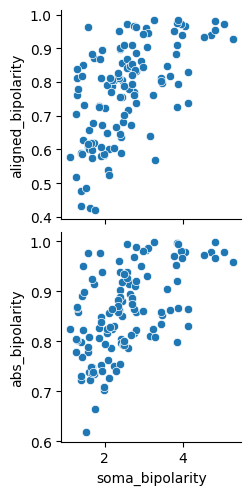

In [124]:
r_mean = np.linalg.norm(df[["radii_0","radii_1"]], axis=1)
r_mean = np.sqrt(df["radii_0"] * df["radii_1"])
r_mean = df["radii_1"]
df["soma_bipolarity"] = df["radii_2"] / r_mean
df["soma_bipolarity_coeff"] = (df["radii_2"] - r_mean)/df["radii_2"]
# df["soma_bipolarity"] = df["radii_2"] / np.sqrt(df["radii_0"]*df["radii_1"])

sns.pairplot(df, y_vars=["aligned_bipolarity", "abs_bipolarity"], x_vars=["soma_bipolarity",])
# "soma_bipolarity_coeff"

In [125]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

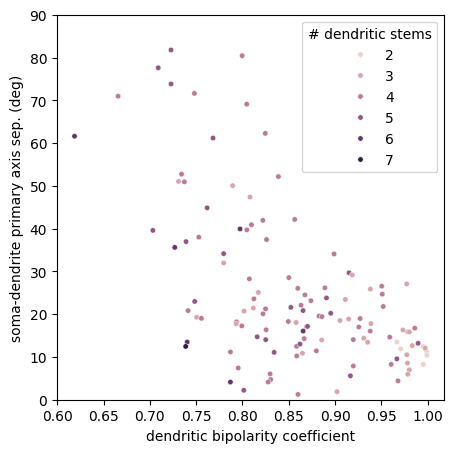

In [126]:
df["primary_axis_angle"] = df["cos_primary_axis"].map(np.arccos).map(np.degrees)

plt.figure(figsize=(5,5))
sns.scatterplot(data=df, y="primary_axis_angle", x="abs_bipolarity", hue="num_stems", s=15)
plt.xlabel("dendritic bipolarity coefficient")
plt.ylabel("soma-dendrite primary axis sep. (deg)")
plt.ylim(0,90)
# legend title
plt.legend(title="# dendritic stems")

In [48]:
# outliers
pd.set_option('display.max_columns', None)
df.query("primary_axis_angle>40 & soma_bipolarity>3")

,soma,soma_offset,radii,volume,rsquared,primary_axis,path,brain,radii_0,radii_1,radii_2,primary_axis_0,primary_axis_1,primary_axis_2,soma_offset_0,soma_offset_1,soma_offset_2,soma_0,soma_1,soma_2,aligned_bipolar_frac,aligned_bipolarity,abs_bipolarity,cos_primary_axis,aligned_bipolar_frac_offset,aligned_bipolarity_offset,abs_bipolarity_offset,cos_primary_axis_offset,num_stems,soma_bipolarity,soma_bipolarity_coeff,primary_axis_angle
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
N008-721332,"[15001.242609, 11292.359168, 13358.882011]","[-18.768, 0., -12.72727273]","[27.02055688, 30.60320858, 100.73729402]",348931.476119,0.789251,"[0.99116648, 0.11709563, 0.0622705]",/data/lc_image_space_reconstructions/721332-im...,721332,27.020557,30.603209,100.737294,0.991166,0.117096,0.06227,-18.768,0.0,-12.727273,15001.242609,11292.359168,13358.882011,0.0,0.568867,0.808062,0.677109,0.0,0.683291,0.718758,0.994431,3,3.291723,0.696208,47.381865


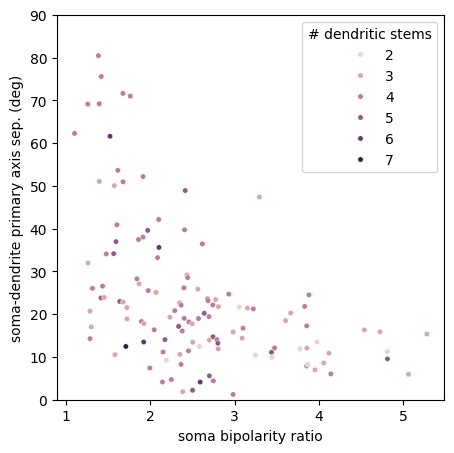

In [47]:

plt.figure(figsize=(5,5))
sns.scatterplot(data=df, y="primary_axis_angle", x="soma_bipolarity", hue="num_stems", s=15)
plt.xlabel("soma bipolarity ratio")
plt.ylabel("soma-dendrite primary axis sep. (deg)")
plt.ylim(0,90)
# legend title
plt.legend(title="# dendritic stems")

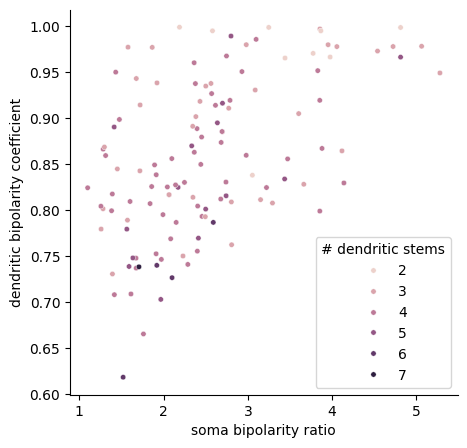

In [49]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df, x="soma_bipolarity", y="abs_bipolarity", hue="num_stems", s=15)
plt.ylabel("dendritic bipolarity coefficient")
plt.xlabel("soma bipolarity ratio")
plt.legend(title="# dendritic stems")
sns.despine()
plt.savefig("/results/soma_vs_dend_bipolarity.pdf")
plt.savefig("/results/soma_vs_dend_bipolarity.svg")

Two bipolarity coefficients are highly correlated - we can aggregate them via harmonic mean to a single coefficient

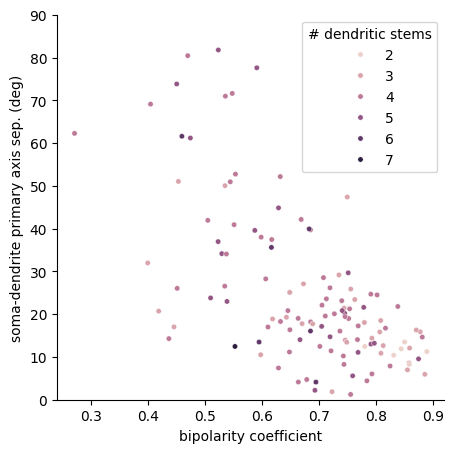

In [132]:

df["bipolarity"] = np.sqrt(df["abs_bipolarity"] * df["soma_bipolarity_coeff"])
plt.figure(figsize=(5,5))
sns.scatterplot(data=df, y="primary_axis_angle", x="bipolarity", hue="num_stems", s=15)
plt.xlabel("bipolarity coefficient")
plt.ylabel("soma-dendrite primary axis sep. (deg)")
plt.ylim(0,90)
# legend title
plt.legend(title="# dendritic stems")
sns.despine()
plt.savefig("/results/bipolarity_axis_separation.pdf")
plt.savefig("/results/bipolarity_axis_separation.svg")

In [51]:
df.query("bipolarity<0.3")

,soma,soma_offset,radii,volume,rsquared,primary_axis,path,brain,radii_0,radii_1,radii_2,primary_axis_0,primary_axis_1,primary_axis_2,soma_offset_0,soma_offset_1,soma_offset_2,soma_0,soma_1,soma_2,aligned_bipolar_frac,aligned_bipolarity,abs_bipolarity,cos_primary_axis,aligned_bipolar_frac_offset,aligned_bipolarity_offset,abs_bipolarity_offset,cos_primary_axis_offset,num_stems,soma_bipolarity,soma_bipolarity_coeff,primary_axis_angle,bipolarity
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
N057-685221,"[31712.149585, 9807.284999, 11156.663078]","[-8.976, 2.65955556, -8.88888889]","[16.43488483, 43.69198499, 47.9880494]",144341.145444,0.641888,"[-0.82547551, 0.40510294, -0.39304171]",/data/lc_image_space_reconstructions/685221-im...,685221,16.434885,43.691985,47.988049,-0.825476,0.405103,-0.393042,-8.976,2.659556,-8.888889,31712.149585,9807.284999,11156.663078,0.0,0.577569,0.824678,0.465457,0.0,0.675997,0.828801,0.70295,4,1.098326,0.089524,62.260208,0.271713


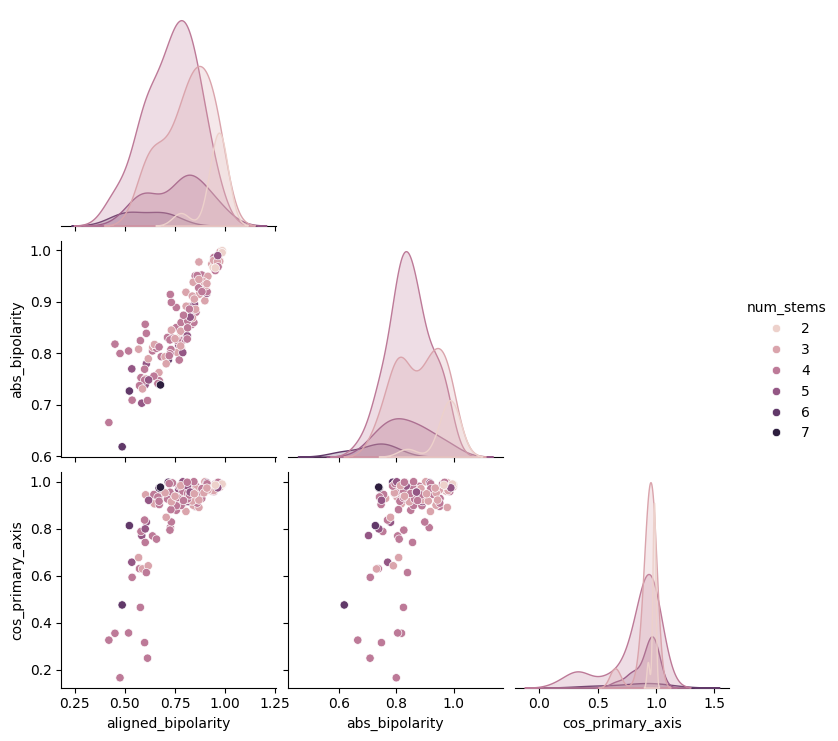

In [53]:
names = ["aligned_bipolarity","abs_bipolarity", "cos_primary_axis"]
# df.loc[index, "mean_bipolarity"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals]
# df.loc[index, "mean_bipolarity_offset"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals_offset]
sns.pairplot(df, vars=names, corner=True, hue="num_stems")

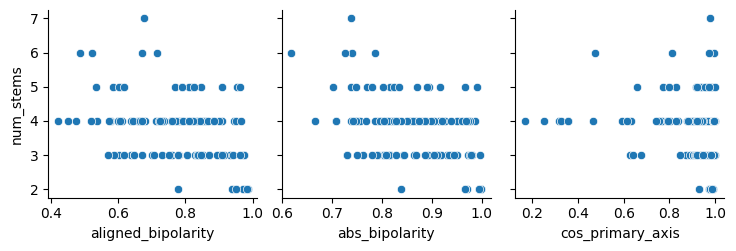

In [54]:

# df.loc[index, "mean_bipolarity"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals]
# df.loc[index, "mean_bipolarity_offset"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals_offset]
sns.pairplot(df, y_vars=["num_stems"], x_vars=names)

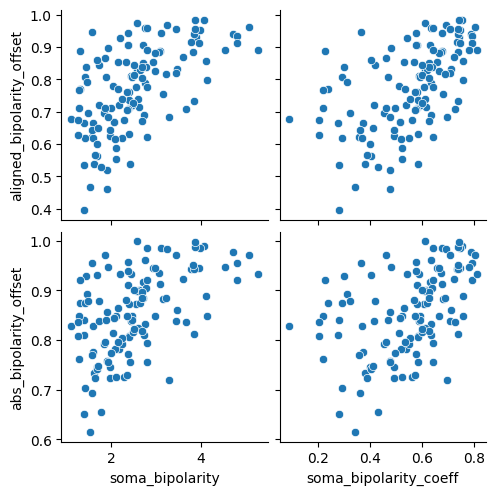

In [55]:
sns.pairplot(df, y_vars=["aligned_bipolarity_offset", "abs_bipolarity_offset"], x_vars=["soma_bipolarity","soma_bipolarity_coeff"])

# CCF coords from csv

In [106]:

from neuron_morphology.feature_extractor.feature_extractor import FeatureExtractor
from neuron_morphology.swc_io import morphology_from_swc
from neuron_morphology.feature_extractor.data import Data
from neuron_morphology.features.size import total_length
from neuron_morphology.feature_extractor.marked_feature import specialize
from neuron_morphology.feature_extractor.feature_specialization import AxonSpec, DendriteSpec

import logging
logging.getLogger('neuron_morphology').setLevel(logging.WARNING)

features = [
    specialize(total_length, {AxonSpec, DendriteSpec})
]

records = []
for id in tqdm(df.index):
    swc = df.loc[id, "path"]
    morph = morphology_from_swc(swc)
    extractor = FeatureExtractor(features)
    run = extractor.extract(
        Data(morph)
    )
    records.append(dict(id=id, **run.results))

  0%|          | 0/132 [00:00<?, ?it/s]2026-02-09 22:58:04,585 root         INFO     selected marks: <bound method FeatureExtractionRun.select_marks of <neuron_morphology.feature_extractor.feature_extraction_run.FeatureExtractionRun object at 0x7ff7b8bf7a30>>
2026-02-09 22:58:04,586 root         INFO     selected features: ['axon.total_length', 'dendrite.total_length']
  1%|          | 1/132 [00:01<02:39,  1.22s/it]2026-02-09 22:58:06,286 root         INFO     selected marks: <bound method FeatureExtractionRun.select_marks of <neuron_morphology.feature_extractor.feature_extraction_run.FeatureExtractionRun object at 0x7ff7bf9b4c40>>
2026-02-09 22:58:06,286 root         INFO     selected features: ['axon.total_length', 'dendrite.total_length']
  2%|▏         | 2/132 [00:03<03:55,  1.81s/it]2026-02-09 22:58:08,237 root         INFO     selected marks: <bound method FeatureExtractionRun.select_marks of <neuron_morphology.feature_extractor.feature_extraction_run.FeatureExtractionRun object 

In [107]:
df_summary = pd.DataFrame.from_records(records, index="id")
df_summary.head()

,axon.total_length,dendrite.total_length
id,,
N010-685222,6.066901e+05,8047.128876
N038-685222,1.028261e+06,9905.539377
N008-685222,1.275827e+05,8727.740578
N009-685222,2.870565e+05,7517.387010
N026-685222,9.027009e+05,8761.320113


In [108]:
import json

coords = ["somaML","somaDV","somaAP"][::-1]
df_summary[coords] = np.nan
from glob import glob
records = {}
for id in tqdm(df_summary.index):
    files = glob(f"/data/*/Complete_annotated/{id}*.json")
    swc = files[0]
    # soma = pd.read_csv(swc, sep=" ", nrows=1, names=["0","1","x","y","z","2","3"], usecols=["x","y","z"])
    with open(swc, 'r') as f:
        data = json.load(f)
    neuron = data["neurons"][0]
    soma = neuron["soma"]
    df_summary.loc[id, coords] = [soma[i] for i in "xyz"]

  0%|          | 0/132 [00:00<?, ?it/s]

100%|██████████| 132/132 [00:16<00:00,  8.08it/s]


In [139]:
df_summary["z"] = df_summary["somaML"]
df_summary["somaML"] = np.minimum(df_summary["z"], 11400-df_summary["z"])

In [75]:
import trimesh
# 
# Load mesh
mesh = trimesh.load('/root/capsule/data/lc_meshes/20250418_transformed_remesh_10.obj')

2026-02-09 22:32:06,639 trimesh.util INFO     triangulating faces


In [140]:
# df_summary = pd.read_csv("/data/LC Morphology Summary.csv")
# df_summary.index = df_summary["Graph"].str[:-3]
df_merged = df.merge(df_summary, left_index=True, right_index=True)
df_merged.columns

Index(['soma', 'soma_offset', 'radii', 'volume', 'rsquared', 'primary_axis',
       'path', 'brain', 'radii_0', 'radii_1', 'radii_2', 'primary_axis_0',
       'primary_axis_1', 'primary_axis_2', 'soma_offset_0', 'soma_offset_1',
       'soma_offset_2', 'soma_0', 'soma_1', 'soma_2', 'aligned_bipolar_frac',
       'aligned_bipolarity', 'abs_bipolarity', 'cos_primary_axis',
       'aligned_bipolar_frac_offset', 'aligned_bipolarity_offset',
       'abs_bipolarity_offset', 'cos_primary_axis_offset', 'num_stems',
       'soma_bipolarity', 'soma_bipolarity_coeff', 'primary_axis_angle',
       'bipolarity', 'axon.total_length', 'dendrite.total_length', 'somaAP',
       'somaDV', 'somaML', 'z'],
      dtype='object')

In [134]:
df.index.difference(df_summary.index)

Index([], dtype='object', name='id')

In [135]:
df_summary.index.difference(df.index)

Index([], dtype='object', name='id')

In [ ]:
import utils
# from importlib import reload
# reload(utils)

<module 'utils' from '/code/utils.py'>

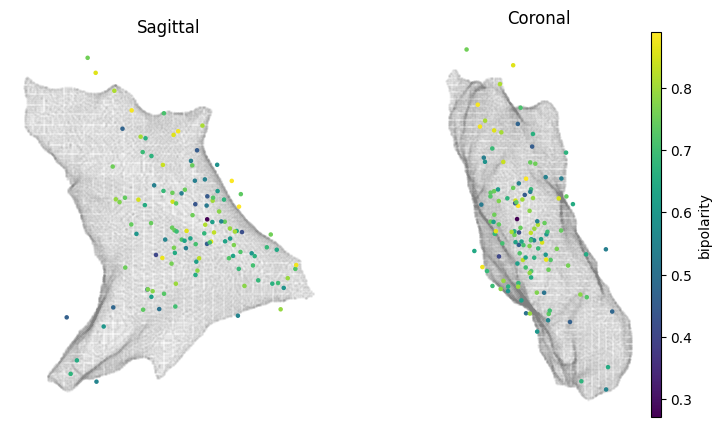

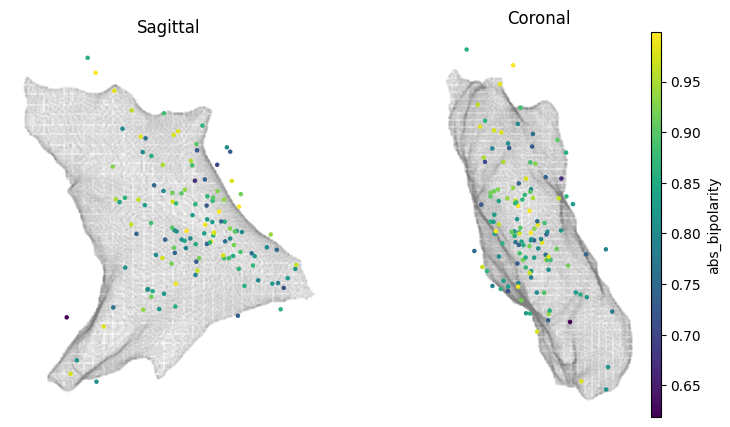

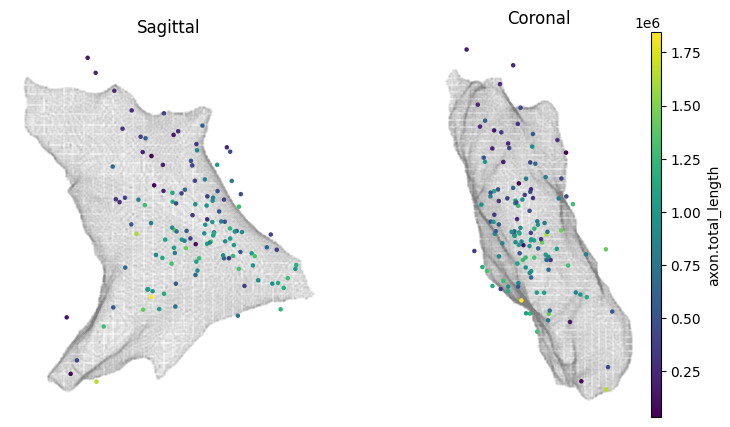

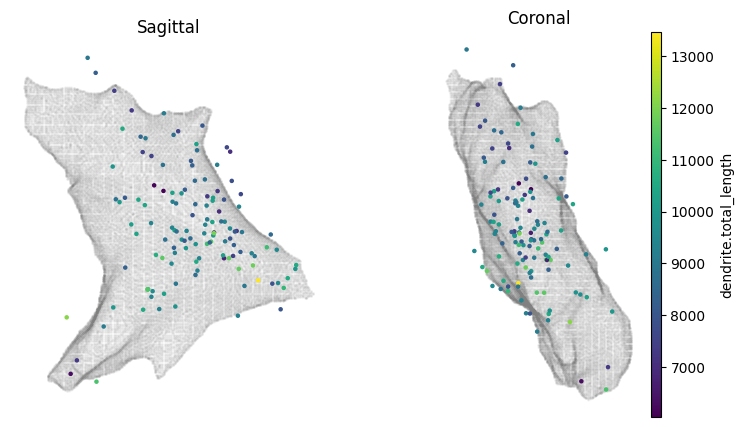

In [141]:
coords = ["somaML","somaDV","somaAP"][::-1]
df_plot = df_merged.query("somaDV<5500 & somaML>4300")
# print(f"{len(df_plot)=}")
cols = [
    "bipolarity", 
    "abs_bipolarity", 
    # "Dendrite Length (cm)",
    # "Axon Length (cm)",
    "axon.total_length",
    "dendrite.total_length",
]
for col in cols:
    utils.two_view_plot_df(df_plot, col, coords, mesh=mesh, s=5)
    plt.savefig(f"/results/spatialplot-{col}.pdf")
    plt.savefig(f"/results/spatialplot-{col}.svg")

In [142]:
df_merged.loc[lambda df: df['dendrite.total_length']>18000]

,soma,soma_offset,radii,volume,rsquared,primary_axis,path,brain,radii_0,radii_1,radii_2,primary_axis_0,primary_axis_1,primary_axis_2,soma_offset_0,soma_offset_1,soma_offset_2,soma_0,soma_1,soma_2,aligned_bipolar_frac,aligned_bipolarity,abs_bipolarity,cos_primary_axis,aligned_bipolar_frac_offset,aligned_bipolarity_offset,abs_bipolarity_offset,cos_primary_axis_offset,num_stems,soma_bipolarity,soma_bipolarity_coeff,primary_axis_angle,bipolarity,axon.total_length,dendrite.total_length,somaAP,somaDV,somaML,z
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
N026-648434,"[30324.927904, 14160.058789, 10062.895872]","[2.49333333, -14.96, -13.66666667]","[25.5851016, 31.91264036, 50.7350011]",173518.65283,0.835778,"[0.9045538, 0.11646591, -0.41014401]",/data/lc_image_space_reconstructions/648434-im...,648434,25.585102,31.91264,50.735001,0.904554,0.116466,-0.410144,2.493333,-14.96,-13.666667,30324.927904,14160.058789,10062.895872,0.0,0.601714,0.739101,0.799062,0.0,0.617769,0.82737,0.762955,5,1.589809,0.370994,36.959344,0.523643,90404.642463,18122.411299,9805.1909,5907.0996,4330.8163,4330.8163


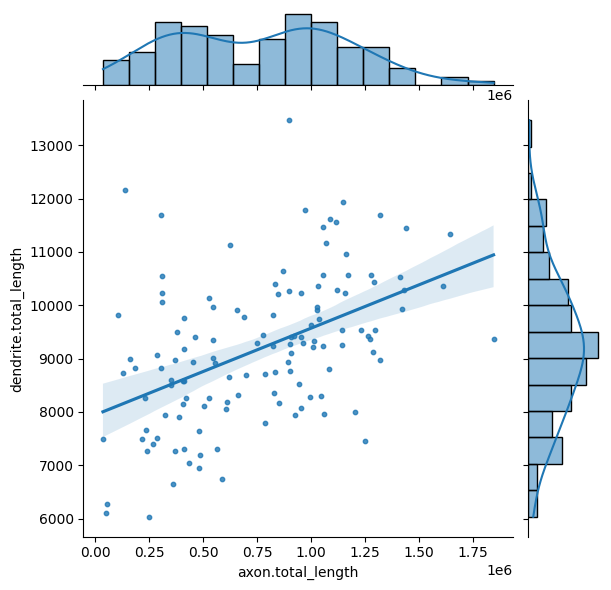

In [152]:
x, y = "axon.total_length", "dendrite.total_length"
# df_plot = df_merged
sns.jointplot(df_plot, x=x, y=y,
scatter_kws=dict(s=10), kind="reg",
marginal_kws=dict(bins=15))

plt.savefig(f"/results/dend_vs_axon.pdf")
plt.savefig(f"/results/dend_vs_axon.svg")

<AxesSubplot:xlabel='bipolarity', ylabel='somaDV'>

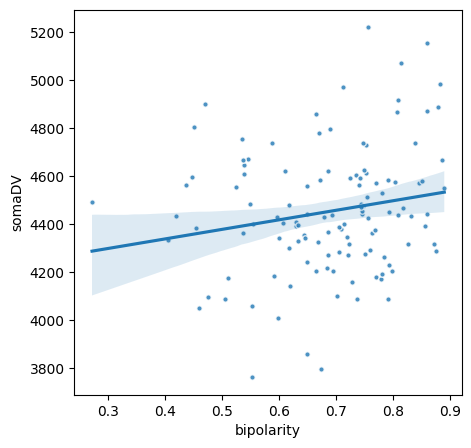

In [ ]:
# downward in refs (reverse)
plt.figure(figsize=(5,5))
y="somaDV"
x="bipolarity"
# sns.regplot(data=df_merged.query("somaDV<5500"), y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
# sns.regplot(data=df_merged.query("somaDV<5500 & somaML>4300"), y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
sns.regplot(data=df_plot, y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})

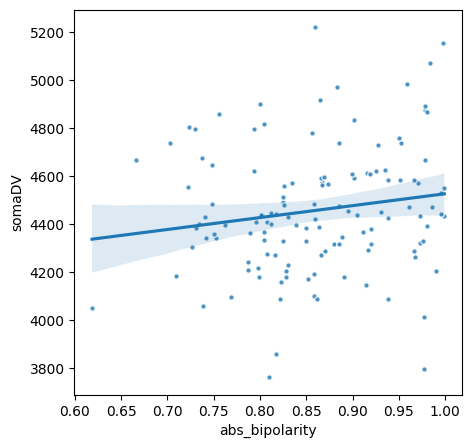

In [160]:
# downward in refs (reverse)
plt.figure(figsize=(5,5))
y="somaDV"
x="abs_bipolarity"
# sns.regplot(data=df_merged.query("somaDV<5500"), y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
sns.regplot(data=df_plot, y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
plt.savefig(f"/results/regression_{x}-{y}.pdf")

<AxesSubplot:xlabel='bipolarity', ylabel='somaAP'>

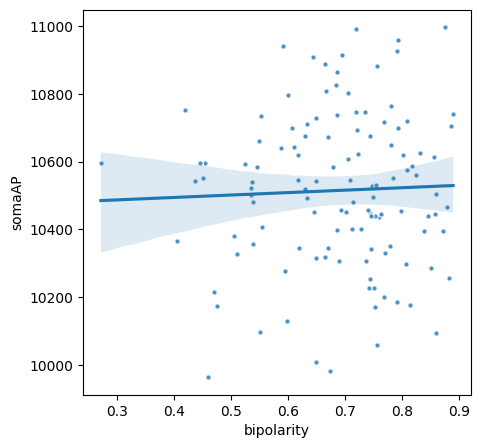

In [ ]:
# increasing in refs
plt.figure(figsize=(5,5))
y="somaAP"
x="bipolarity"
sns.regplot(data=df_plot, y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})

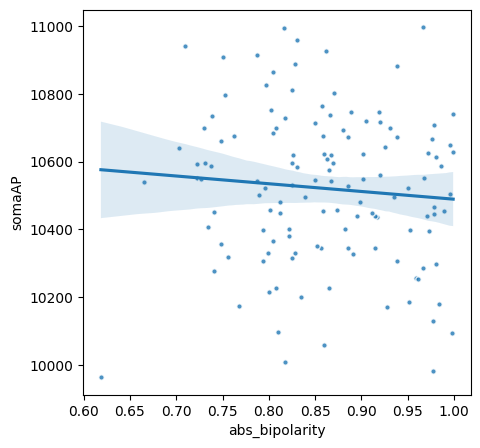

In [159]:
# increasing in refs (reverse)
plt.figure(figsize=(5,5))
y="somaAP"
x="abs_bipolarity"
sns.regplot(data=df_plot, y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
plt.savefig(f"/results/regression_{x}-{y}.pdf")

In [48]:
df.to_csv("/scratch/lc_somas.csv")

## Locations (not CCF-aligned)

<AxesSubplot:xlabel='soma_0', ylabel='soma_1'>

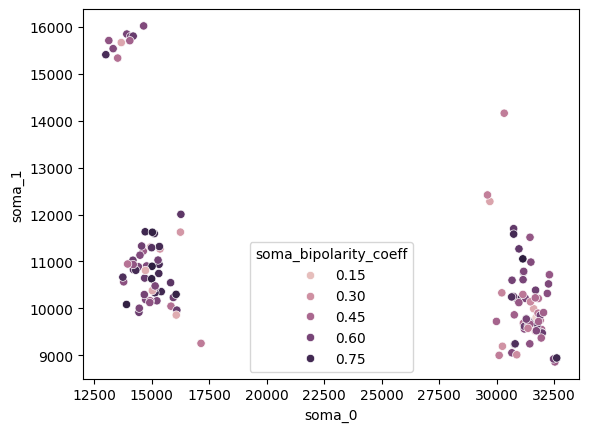

In [11]:
sns.scatterplot(df, x="soma_0", y="soma_1", hue="soma_bipolarity_coeff")

<AxesSubplot:xlabel='soma_0', ylabel='soma_1'>

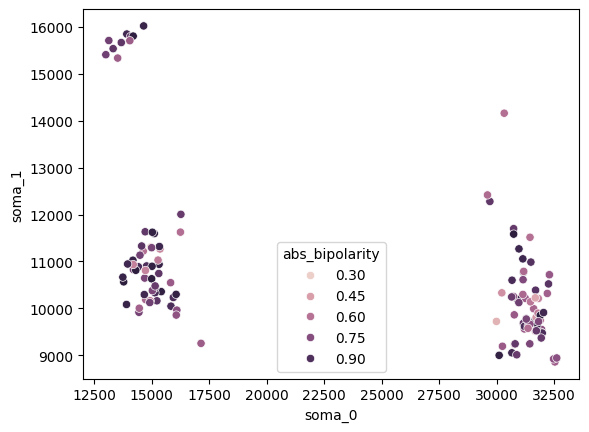

In [12]:
sns.scatterplot(df, x="soma_0", y="soma_1", hue="abs_bipolarity")